<div align="center" >
    <br /><br />
    <h1>Universidad de Sevilla</h1>
    <h2>Escuela Técnica Superior de Ingeniería Informática</h2>
    <h3>Grado en Ingeniería del Software</h3>
    <img src="images/logo_us.png" alt="Logo Universidad de Sevilla" width="250" />
    <br />
    <hr />
    <br />
    <h1>Evaluación y selección del mejor modelo</h1>
    <h2>Comparativa final entre enfoque manual y Node2Vec</h2>
    <br />
    <hr />
    <br />
    <p><strong>Asignatura:</strong> Inteligencia Artificial</p>
    <p><strong>Grupo:</strong> Aprendizaje Automático Relacional - G5</p>
    <p><strong>Curso Académico:</strong> 2025/2026</p>
</div>

<br /><br /><br /><br />

<div align="right" >
    <p><strong>Autores:</strong><br />
    Juan Antonio Fernández Ruiz<br />
    Eulogio Reyes Díaz<br />
</div>

<div align="right" >
    <p><strong>Fecha:</strong> 7 de Junio de 2026</p>
</div>

<br /><br />

# Evaluación y selección del mejor modelo

## 0. Introducción y objetivo

El objetivo de esta tarea es comparar formalmente la estrategia basada en características manuales frente a la estrategia basada en representaciones latentes (Node2Vec), seleccionar el modelo definitivo del proyecto y dejar preparado su guardado para carga posterior.

Esta decisión final integra evidencia empírica (métricas) y fundamento teórico sobre representación de nodos en grafos.

## Indice de contenidos

- [0. Introduccion y objetivo](#0-introduccion-y-objetivo)
- [1. Configuracion inicial](#1-configuracion-inicial)
- [2. Carga de resultados y comparacion cuantitativa](#2-carga-de-resultados-y-comparación-cuantitativa)
- [3. Comparativa visual de desempeno](#3-comparativa-visual-de-desempeño)
- [4. Analisis critico y seleccion del modelo](#4-análisis-crítico-y-selección-del-modelo)
- [5. Persistencia del modelo definitivo](#5-persistencia-del-modelo-definitivo)
- [6. Conclusiones y siguientes pasos](#6-conclusiones-y-siguientes-pasos)

## 1. Configuracion inicial

Importamos librerias para analisis tabular, visualizacion y persistencia del modelo definitivo.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

sns.set_style("whitegrid")

## 2. Carga de resultados y comparación cuantitativa

Se localizan automáticamente los artefactos más recientes de las tareas 2.1 y 2.5 para construir la tabla comparativa entre estrategias.

In [9]:
def _resolve_base_dir() -> Path:
    cwd = Path.cwd()
    if (cwd / "artifacts").exists():
        return cwd
    if (cwd.parent / "artifacts").exists():
        return cwd.parent
    raise FileNotFoundError("No se encontro la carpeta artifacts desde el directorio actual.")

def _latest_result_file(task_dir: Path) -> Path:
    candidates = sorted(task_dir.glob("*/resumen_test*.csv"))
    if not candidates:
        raise FileNotFoundError(
            f"No se encontro resumen_test*.csv en {task_dir}. "
            "Ejecuta y guarda artefactos de la tarea correspondiente."
        )
    return candidates[-1]

BASE_DIR = _resolve_base_dir()
resumen_t21_path = _latest_result_file(BASE_DIR / "artifacts" / "tarea_2_1")
resumen_t25_path = _latest_result_file(BASE_DIR / "artifacts" / "tarea_2_5")

resumen_manual = pd.read_csv(resumen_t21_path)
resumen_n2v = pd.read_csv(resumen_t25_path)

mejor_manual = resumen_manual.sort_values("f1_macro", ascending=False).iloc[0]
mejor_n2v = resumen_n2v.sort_values("f1_macro", ascending=False).iloc[0]

comparativa = pd.DataFrame([
    {
        "Estrategia": "Manual",
        "Modelo": mejor_manual["modelo"],
        "F1_macro": float(mejor_manual["f1_macro"]),
        "Accuracy": float(mejor_manual["accuracy"]),
    },
    {
        "Estrategia": "Node2Vec",
        "Modelo": mejor_n2v["modelo"],
        "F1_macro": float(mejor_n2v["f1_macro"]),
        "Accuracy": float(mejor_n2v["accuracy"]),
    },
])

display(comparativa.style.format({"F1_macro": "{:.3f}", "Accuracy": "{:.3f}"}))
print(f"Fuente Manual: {resumen_t21_path}")
print(f"Fuente Node2Vec: {resumen_t25_path}")

,Estrategia,Modelo,F1_macro,Accuracy
0,Manual,ArbolDecision,0.759,0.771
1,Node2Vec,kNN,0.869,0.875


Fuente Manual: c:\Users\juana\aprendizaje-automatico-relacional\artifacts\tarea_2_1\20260527_124833\resumen_test.csv
Fuente Node2Vec: c:\Users\juana\aprendizaje-automatico-relacional\artifacts\tarea_2_5\20260606_190842\resumen_test.csv


## 3. Comparativa visual de desempeño

Se visualiza el F1-macro de los modelos ganadores por estrategia para facilitar una decisión de selección clara y trazable.

C:\Users\juana\AppData\Local\Temp\ipykernel_23672\3592626103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=comparativa, x="Modelo", y="F1_macro", palette=["#5E81AC", "#A3BE8C"])


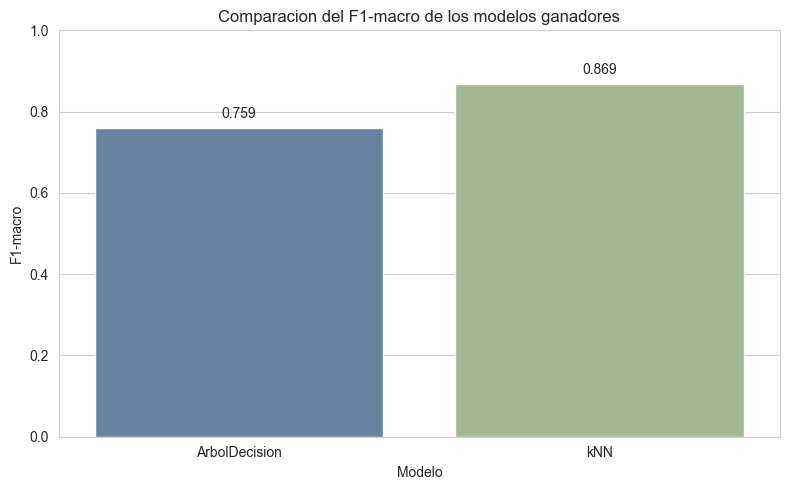

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=comparativa, x="Modelo", y="F1_macro", palette=["#5E81AC", "#A3BE8C"])

ax.set_title("Comparacion del F1-macro de los modelos ganadores", fontsize=12)
ax.set_xlabel("Modelo")
ax.set_ylabel("F1-macro")
ax.set_ylim(0, 1.0)

for p in ax.patches:
    valor = p.get_height()
    ax.annotate(f"{valor:.3f}",
                (p.get_x() + p.get_width() / 2, valor),
                ha="center", va="bottom",
                fontsize=10, xytext=(0, 5),
                textcoords="offset points")

plt.tight_layout()
plt.show()

## 4. Análisis crítico y selección del modelo

Se selecciona como modelo definitivo **kNN con representaciones Node2Vec**. La evidencia cuantitativa observada en esta ejecución muestra una mejora aproximada de 11 puntos en F1-macro respecto al mejor modelo con características manuales: 0.759 frente a 0.869, es decir, **+0.110**.

Desde el punto de vista teórico, kNN es un algoritmo basado en distancias. En el espacio original de 1437 características, altamente disperso (aprox. 98% de ceros), la distancia euclídea pierde capacidad discriminativa por la maldición de la dimensionalidad. En cambio, al usar embeddings densos de 64 dimensiones generados por Node2Vec, las distancias entre nodos se vuelven más informativas porque estos vectores preservan la topología local de la red (homofilia), facilitando una mejor separación entre clases.

## 5. Persistencia del modelo definitivo

Se recupera el modelo ganador desde los artefactos reales de la Tarea 2.5 y se guarda en `artifacts/tarea_2_3/` para su reutilización en etapas posteriores.

In [11]:
def _resolve_base_dir() -> Path:
    cwd = Path.cwd()
    if (cwd / "artifacts").exists():
        return cwd
    if (cwd.parent / "artifacts").exists():
        return cwd.parent
    raise FileNotFoundError("No se encontro la carpeta artifacts desde el directorio actual.")

def _latest_result_file(task_dir: Path) -> Path:
    candidates = sorted(task_dir.glob("*/resumen_test*.csv"))
    if not candidates:
        raise FileNotFoundError(
            f"No se encontro resumen_test*.csv en {task_dir}. "
            "Ejecuta y guarda artefactos de la tarea correspondiente."
        )
    return candidates[-1]

def _normalize_name(text: str) -> str:
    return "".join(ch.lower() for ch in text if ch.isalnum())

BASE_DIR = _resolve_base_dir()
t25_dir = BASE_DIR / "artifacts" / "tarea_2_5"
resumen_t25_path = _latest_result_file(t25_dir)
run_dir = resumen_t25_path.parent

resumen_n2v = pd.read_csv(resumen_t25_path)
mejor_n2v = resumen_n2v.sort_values("f1_macro", ascending=False).iloc[0]
mejor_nombre = str(mejor_n2v["modelo"])

cand_modelos = sorted(run_dir.glob("modelo_*.joblib"))
if not cand_modelos:
    raise FileNotFoundError(
        f"No se encontro ningun modelo_*.joblib en {run_dir}. "
        "Guarda el mejor estimador real en Tarea 2.5 antes de ejecutar esta celda."
    )

target_norm = _normalize_name(mejor_nombre)
modelo_origen = None
for c in cand_modelos:
    model_norm = _normalize_name(c.stem.replace("modelo_", ""))
    if model_norm == target_norm:
        modelo_origen = c
        break

if modelo_origen is None:
    disponibles = ", ".join(c.name for c in cand_modelos)
    raise FileNotFoundError(
        f"No hay un .joblib que coincida con el mejor modelo '{mejor_nombre}' en {run_dir}. "
        f"Modelos encontrados: {disponibles}"
    )

best_knn_pipeline = joblib.load(modelo_origen)

salida_dir = BASE_DIR / "artifacts" / "tarea_2_3"
salida_dir.mkdir(parents=True, exist_ok=True)
ruta_modelo = salida_dir / "modelo_definitivo_kNN_Node2Vec.joblib"

joblib.dump(best_knn_pipeline, ruta_modelo)
modelo_cargado = joblib.load(ruta_modelo)

print("El modelo definitivo ha sido seleccionado y guardado con éxito")
print(f"Modelo origen: {modelo_origen}")
print(f"Archivo generado: {ruta_modelo.resolve()}")
print(f"Tipo de objeto cargado: {type(modelo_cargado)}")

El modelo definitivo ha sido seleccionado y guardado con éxito
Modelo origen: c:\Users\juana\aprendizaje-automatico-relacional\artifacts\tarea_2_5\20260606_190842\modelo_kNN.joblib
Archivo generado: C:\Users\juana\aprendizaje-automatico-relacional\artifacts\tarea_2_3\modelo_definitivo_kNN_Node2Vec.joblib
Tipo de objeto cargado: <class 'sklearn.pipeline.Pipeline'>


## 6. Conclusiones y siguientes pasos

- La estrategia Node2Vec + kNN queda seleccionada como solución final del proyecto por mejor desempeño global en F1-macro.
- Se garantiza trazabilidad al guardar el modelo definitivo en `artifacts/tarea_2_3/modelo_definitivo_kNN_Node2Vec.joblib`.
- El siguiente paso natural es consumir este modelo en el informe final y en la defensa, usando los artefactos generados como evidencia reproducible.